# Data Analysis of MOT17 dataset

Loading all the required libraries for the code along with the path of the folders.

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
from pathlib import Path
from collections import defaultdict

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
MOT20_ROOT = Path('C:/Users/HP/Downloads/MOT17 (1)/MOT17')   # change if needed
TRAIN_ROOT = MOT20_ROOT / 'train'
TEST_ROOT  = MOT20_ROOT / 'test'

TRAIN_SEQS = sorted([d.name for d in TRAIN_ROOT.iterdir() if d.is_dir()])
TEST_SEQS  = sorted([d.name for d in TEST_ROOT.iterdir()  if d.is_dir()])

print('Train sequences:', TRAIN_SEQS)
print('Test sequences: ', TEST_SEQS)

Train sequences: ['MOT17-02-DPM', 'MOT17-02-FRCNN', 'MOT17-02-SDP', 'MOT17-04-DPM', 'MOT17-04-FRCNN', 'MOT17-04-SDP', 'MOT17-05-DPM', 'MOT17-05-FRCNN', 'MOT17-05-SDP', 'MOT17-09-DPM', 'MOT17-09-FRCNN', 'MOT17-09-SDP', 'MOT17-10-DPM', 'MOT17-10-FRCNN', 'MOT17-10-SDP', 'MOT17-11-DPM', 'MOT17-11-FRCNN', 'MOT17-11-SDP', 'MOT17-13-DPM', 'MOT17-13-FRCNN', 'MOT17-13-SDP']
Test sequences:  ['MOT17-01-DPM', 'MOT17-01-FRCNN', 'MOT17-01-SDP', 'MOT17-03-DPM', 'MOT17-03-FRCNN', 'MOT17-03-SDP', 'MOT17-06-DPM', 'MOT17-06-FRCNN', 'MOT17-06-SDP', 'MOT17-07-DPM', 'MOT17-07-FRCNN', 'MOT17-07-SDP', 'MOT17-08-DPM', 'MOT17-08-FRCNN', 'MOT17-08-SDP', 'MOT17-12-DPM', 'MOT17-12-FRCNN', 'MOT17-12-SDP', 'MOT17-14-DPM', 'MOT17-14-FRCNN', 'MOT17-14-SDP']


## Dataset Overview 

In [3]:
def load_gt(seq_path):
    """Load ground truth annotations for a sequence.
    MOT format columns: frame, id, x, y, w, h, conf, class, visibility
    """
    gt_path = seq_path / 'gt' / 'gt.txt'
    cols = ['frame','id','x','y','w','h','conf','class','visibility']
    df = pd.read_csv(gt_path, header=None, names=cols)
    # keep only pedestrians (class == 1)
    df = df[df['class'] == 1].reset_index(drop=True)
    return df

def load_seqinfo(seq_path):
    """Parse seqinfo.ini for fps and image dimensions."""
    info = {}
    ini_path = seq_path / 'seqinfo.ini'
    with open(ini_path) as f:
        for line in f:
            if '=' in line:
                k, v = line.strip().split('=')
                info[k.strip()] = v.strip()
    return info

stats = []
seq_data = {}  # store per-sequence DataFrames

for seq in TRAIN_SEQS:
    seq_path = TRAIN_ROOT / seq
    df  = load_gt(seq_path)
    inf = load_seqinfo(seq_path)
    n_frames  = df['frame'].nunique()
    n_ids     = df['id'].nunique()
    n_annots  = len(df)
    fps       = float(inf.get('frameRate', 25))
    duration  = n_frames / fps
    seq_data[seq] = df
    stats.append({
        'Sequence':   seq,
        'Frames':     n_frames,
        'Unique IDs': n_ids,
        'Annotations':n_annots,
        'FPS':        int(fps),
        'Duration(s)':round(duration, 1),
        'Avg persons/frame': round(n_annots / n_frames, 1)
    })

stats_df = pd.DataFrame(stats)
print('=== MOT17 Train — Dataset Statistics ===')
print(stats_df.to_string(index=False))
print(f"\nTOTAL  frames: {stats_df['Frames'].sum()}")
print(f"TOTAL  unique IDs: {stats_df['Unique IDs'].sum()}")
print(f"TOTAL  annotations: {stats_df['Annotations'].sum():,}")

=== MOT17 Train — Dataset Statistics ===
      Sequence  Frames  Unique IDs  Annotations  FPS  Duration(s)  Avg persons/frame
  MOT17-02-DPM     600          62        18581   30         20.0               31.0
MOT17-02-FRCNN     600          62        18581   30         20.0               31.0
  MOT17-02-SDP     600          62        18581   30         20.0               31.0
  MOT17-04-DPM    1050          83        47557   30         35.0               45.3
MOT17-04-FRCNN    1050          83        47557   30         35.0               45.3
  MOT17-04-SDP    1050          83        47557   30         35.0               45.3
  MOT17-05-DPM     837         133         6917   14         59.8                8.3
MOT17-05-FRCNN     837         133         6917   14         59.8                8.3
  MOT17-05-SDP     837         133         6917   14         59.8                8.3
  MOT17-09-DPM     525          26         5325   30         17.5               10.1
MOT17-09-FRCNN     525  

## Sample Frames with Ground Truth Boxes

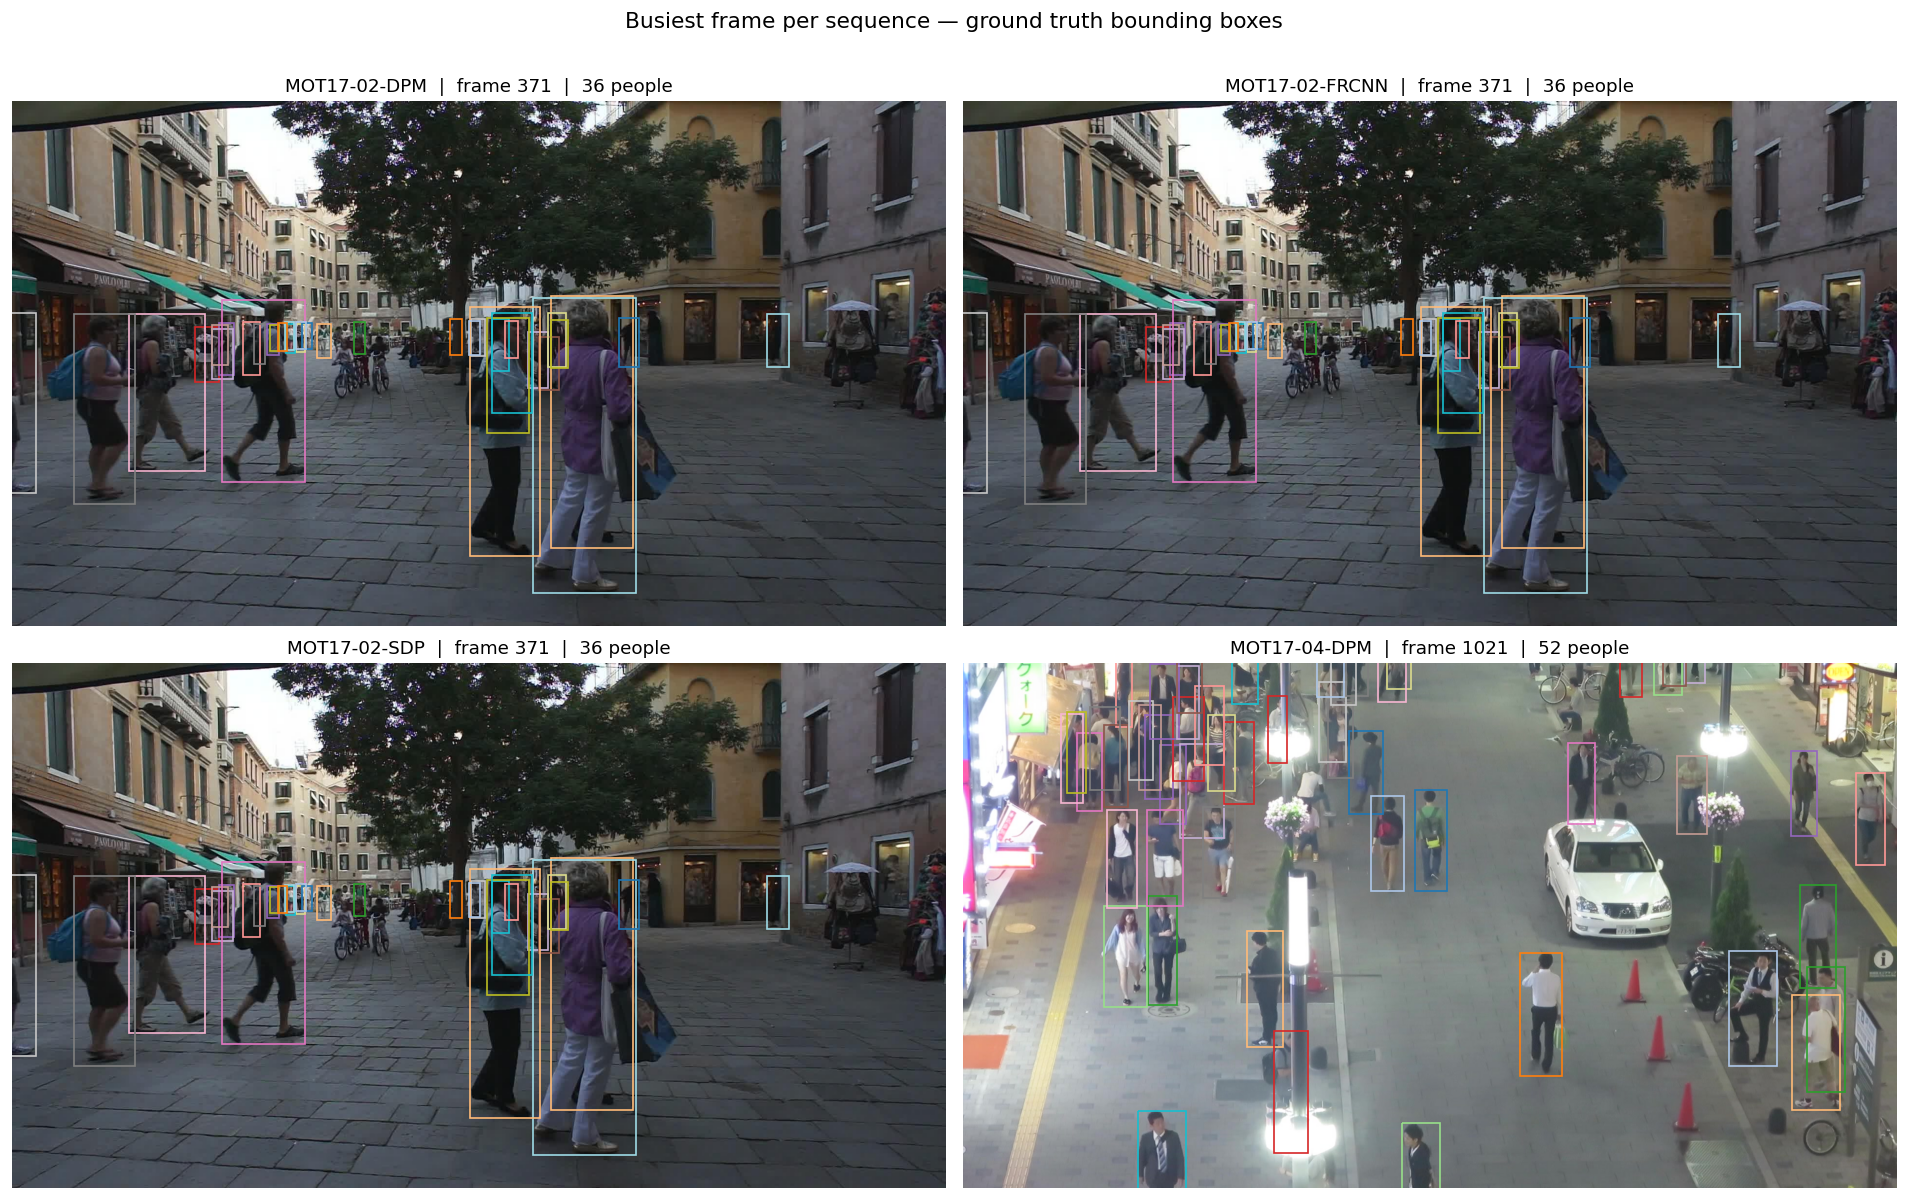

Saved: sample_frames.png


In [5]:
COLORS = plt.cm.tab20.colors

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, seq in enumerate(TRAIN_SEQS[:4]):
    seq_path = TRAIN_ROOT / seq
    df = seq_data[seq]

    # pick the frame with most people for a dramatic view
    busiest_frame = df.groupby('frame').size().idxmax()
    img_file = seq_path / 'img1' / f'{busiest_frame:06d}.jpg'
    img = cv2.cvtColor(cv2.imread(str(img_file)), cv2.COLOR_BGR2RGB)

    ax = axes[idx]
    ax.imshow(img)

    frame_df = df[df['frame'] == busiest_frame]
    for _, row in frame_df.iterrows():
        color = COLORS[int(row['id']) % len(COLORS)]
        rect  = patches.Rectangle(
            (row['x'], row['y']), row['w'], row['h'],
            linewidth=1, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)

    n_people = len(frame_df)
    ax.set_title(f'{seq}  |  frame {busiest_frame}  |  {n_people} people', fontsize=11)
    ax.axis('off')

plt.suptitle('Busiest frame per sequence — ground truth bounding boxes', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('sample_frames.png', bbox_inches='tight')
plt.show()
print('Saved: sample_frames.png')

## Crowd Density — Persons per Frame Distribution

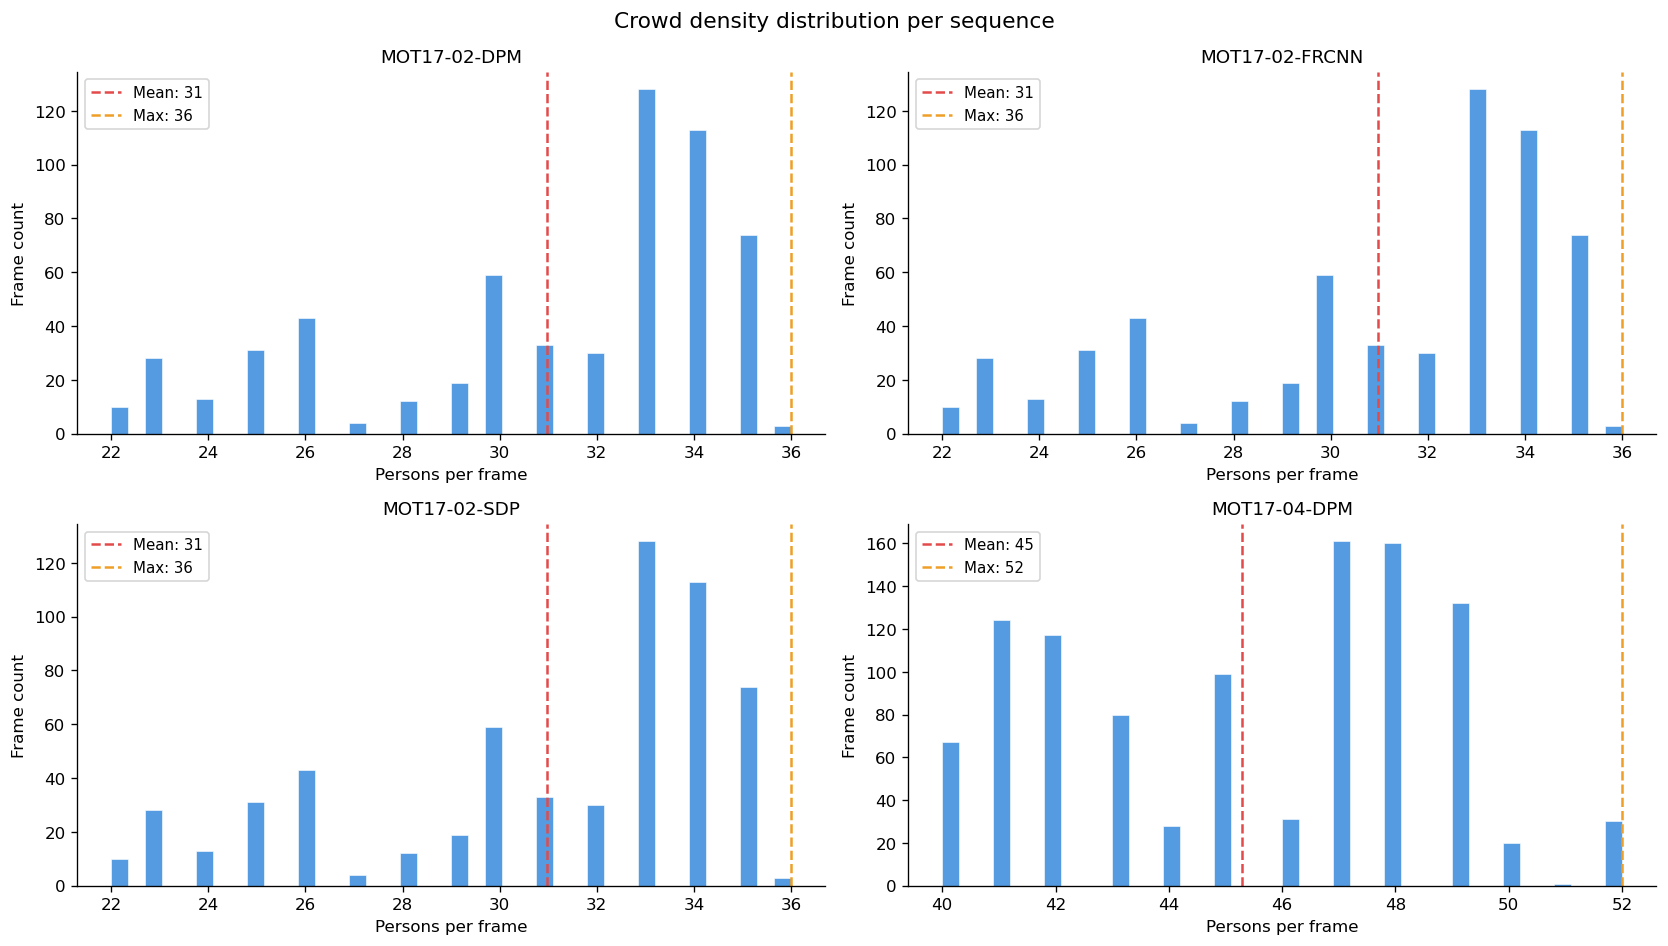

Overall — mean: 36.2 | median: 34.0 | max: 52
Saved: crowd_density_distribution.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

all_densities = []

for idx, seq in enumerate(TRAIN_SEQS[:4]):
    df = seq_data[seq]
    density = df.groupby('frame').size().values
    all_densities.extend(density)

    ax = axes[idx]
    ax.hist(density, bins=40, color='#378ADD', alpha=0.85, edgecolor='white', linewidth=0.4)
    ax.axvline(density.mean(), color='#E24B4A', linestyle='--', linewidth=1.5,
               label=f'Mean: {density.mean():.0f}')
    ax.axvline(density.max(), color='#EF9F27', linestyle='--', linewidth=1.5,
               label=f'Max: {density.max()}')
    ax.set_title(seq, fontsize=11)
    ax.set_xlabel('Persons per frame')
    ax.set_ylabel('Frame count')
    ax.legend(fontsize=9)

plt.suptitle('Crowd density distribution per sequence', fontsize=13)
plt.tight_layout()
plt.savefig('crowd_density_distribution.png', bbox_inches='tight')
plt.show()

all_densities = np.array(all_densities)
print(f'Overall — mean: {all_densities.mean():.1f} | median: {np.median(all_densities):.1f} | max: {all_densities.max()}')
print('Saved: crowd_density_distribution.png')

## Occlusion Analysis — Visibility Score per Sequence

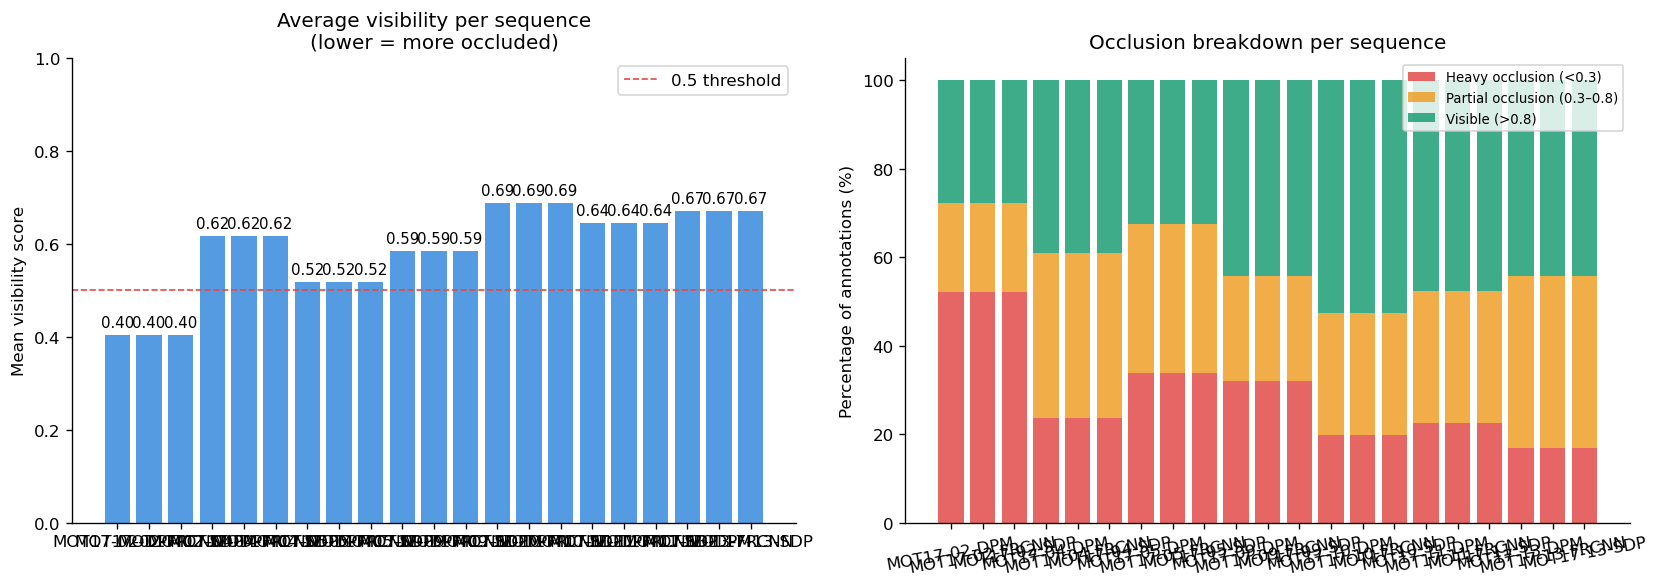

           seq  mean_vis  pct_heavy_occlusion  pct_partial  pct_visible
  MOT17-02-DPM  0.404253            52.020882    20.224961    27.754157
MOT17-02-FRCNN  0.404253            52.020882    20.224961    27.754157
  MOT17-02-SDP  0.404253            52.020882    20.224961    27.754157
  MOT17-04-DPM  0.617697            23.672645    37.205879    39.121475
MOT17-04-FRCNN  0.617697            23.672645    37.205879    39.121475
  MOT17-04-SDP  0.617697            23.672645    37.205879    39.121475
  MOT17-05-DPM  0.518920            33.800781    33.714038    32.485181
MOT17-05-FRCNN  0.518920            33.800781    33.714038    32.485181
  MOT17-05-SDP  0.518920            33.800781    33.714038    32.485181
  MOT17-09-DPM  0.585637            31.981221    23.661972    44.356808
MOT17-09-FRCNN  0.585637            31.981221    23.661972    44.356808
  MOT17-09-SDP  0.585637            31.981221    23.661972    44.356808
  MOT17-10-DPM  0.687904            19.908093    27.393099    52

In [9]:
# MOT20 visibility: 1.0 = fully visible, 0.0 = fully occluded
vis_stats = []
for seq in TRAIN_SEQS:
    df = seq_data[seq]
    vis_stats.append({
        'seq':      seq,
        'mean_vis': df['visibility'].mean(),
        'pct_heavy_occlusion': (df['visibility'] < 0.3).mean() * 100,
        'pct_partial':         ((df['visibility'] >= 0.3) & (df['visibility'] < 0.8)).mean() * 100,
        'pct_visible':         (df['visibility'] >= 0.8).mean() * 100,
    })

vis_df = pd.DataFrame(vis_stats)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Mean visibility bar chart
bars = ax1.bar(vis_df['seq'], vis_df['mean_vis'], color='#378ADD', alpha=0.85)
ax1.set_ylim(0, 1)
ax1.set_ylabel('Mean visibility score')
ax1.set_title('Average visibility per sequence\n(lower = more occluded)')
ax1.axhline(0.5, color='#E24B4A', linestyle='--', linewidth=1, label='0.5 threshold')
ax1.legend()
for bar, val in zip(bars, vis_df['mean_vis']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2f}', ha='center', va='bottom', fontsize=9)

# Stacked bar — occlusion breakdown
x = range(len(TRAIN_SEQS))
ax2.bar(x, vis_df['pct_heavy_occlusion'], label='Heavy occlusion (<0.3)', color='#E24B4A', alpha=0.85)
ax2.bar(x, vis_df['pct_partial'], bottom=vis_df['pct_heavy_occlusion'],
        label='Partial occlusion (0.3–0.8)', color='#EF9F27', alpha=0.85)
ax2.bar(x, vis_df['pct_visible'],
        bottom=vis_df['pct_heavy_occlusion'] + vis_df['pct_partial'],
        label='Visible (>0.8)', color='#1D9E75', alpha=0.85)
ax2.set_xticks(list(x))
ax2.set_xticklabels(TRAIN_SEQS, rotation=10)
ax2.set_ylabel('Percentage of annotations (%)')
ax2.set_title('Occlusion breakdown per sequence')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('occlusion_analysis.png', bbox_inches='tight')
plt.show()

print(vis_df[['seq','mean_vis','pct_heavy_occlusion','pct_partial','pct_visible']].to_string(index=False))
print('Saved: occlusion_analysis.png')

## Bounding Box Overlap Heatmap (Sample Frame)

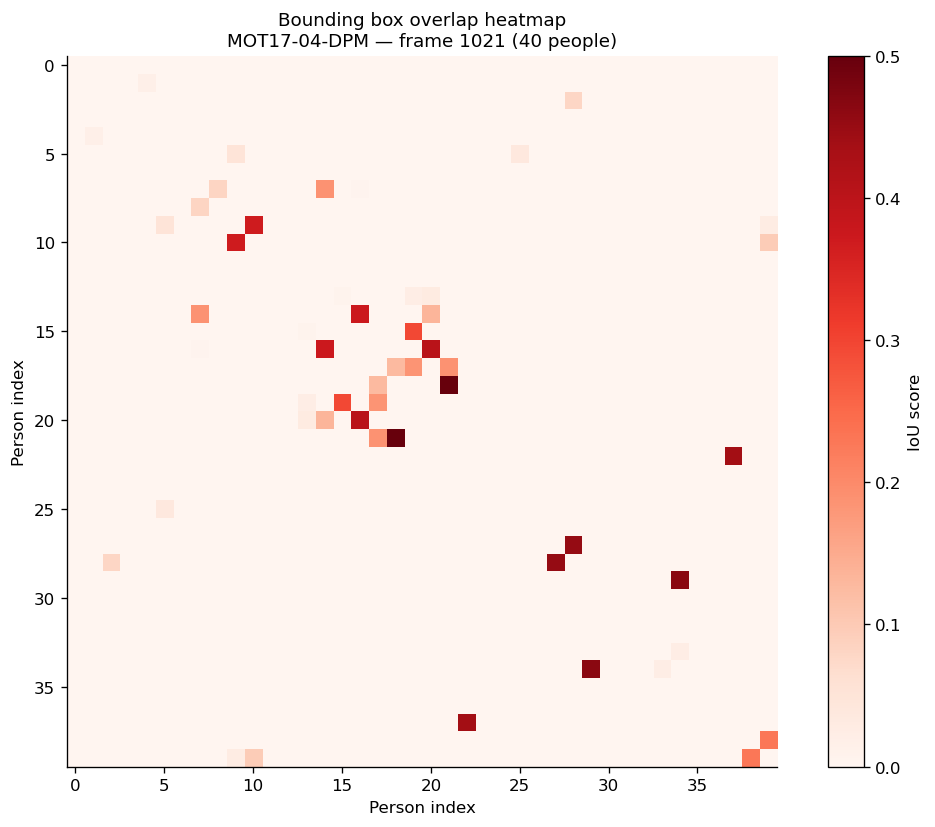

Mean IoU between overlapping boxes: 0.180
Max IoU: 0.552
Pairs with IoU > 0.1: 14
Saved: overlap_heatmap.png


In [10]:
def compute_iou(boxA, boxB):
    """Compute IoU between two boxes [x, y, w, h]."""
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[0]+boxA[2], boxB[0]+boxB[2])
    yB = min(boxA[1]+boxA[3], boxB[1]+boxB[3])
    inter = max(0, xB-xA) * max(0, yB-yA)
    areaA = boxA[2] * boxA[3]
    areaB = boxB[2] * boxB[3]
    union = areaA + areaB - inter
    return inter / union if union > 0 else 0

# Use the busiest sequence's busiest frame
busiest_seq  = max(TRAIN_SEQS, key=lambda s: seq_data[s].groupby('frame').size().max())
df_busy      = seq_data[busiest_seq]
busiest_frame = df_busy.groupby('frame').size().idxmax()
frame_df     = df_busy[df_busy['frame'] == busiest_frame].head(40)  # cap at 40 for readability

boxes = frame_df[['x','y','w','h']].values
n     = len(boxes)
iou_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        if i != j:
            iou_matrix[i, j] = compute_iou(boxes[i], boxes[j])

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(iou_matrix, cmap='Reds', vmin=0, vmax=0.5)
plt.colorbar(im, ax=ax, label='IoU score')
ax.set_title(f'Bounding box overlap heatmap\n{busiest_seq} — frame {busiest_frame} ({n} people)', fontsize=11)
ax.set_xlabel('Person index')
ax.set_ylabel('Person index')
plt.tight_layout()
plt.savefig('overlap_heatmap.png', bbox_inches='tight')
plt.show()

nonzero = iou_matrix[iou_matrix > 0]
print(f'Mean IoU between overlapping boxes: {nonzero.mean():.3f}')
print(f'Max IoU: {iou_matrix.max():.3f}')
print(f'Pairs with IoU > 0.1: {(iou_matrix > 0.1).sum() // 2}')
print('Saved: overlap_heatmap.png')

## Identity / Track Length Distribution

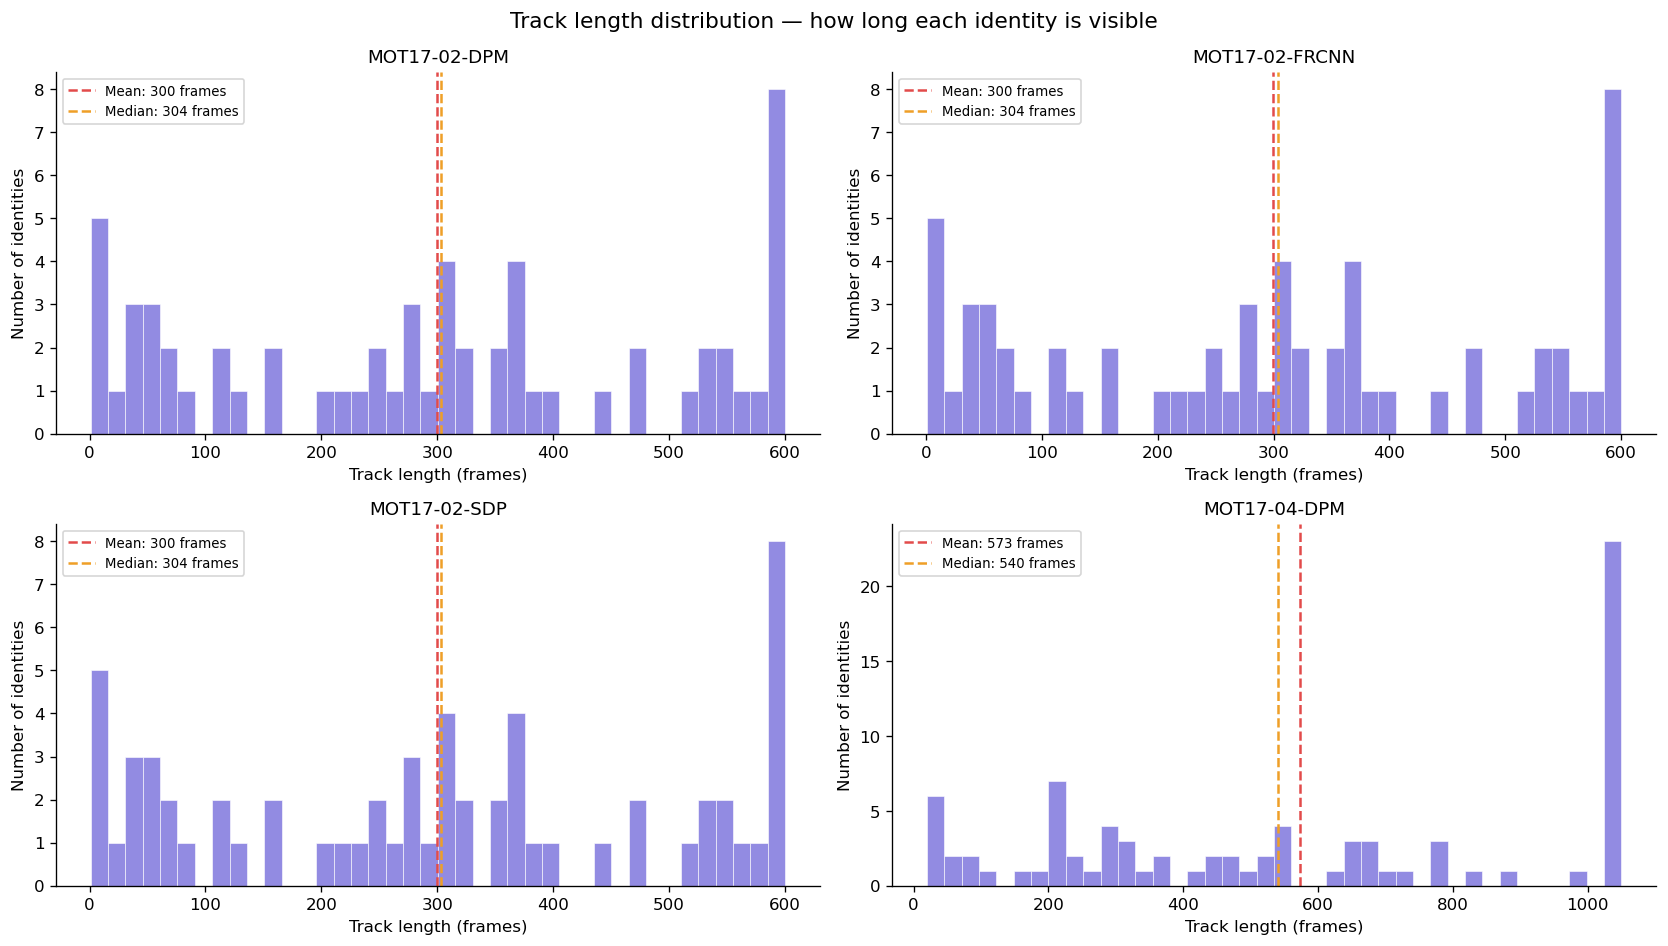

Saved: track_length_distribution.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for idx, seq in enumerate(TRAIN_SEQS[:4]):
    df = seq_data[seq]
    track_lengths = df.groupby('id')['frame'].nunique()

    ax = axes[idx]
    ax.hist(track_lengths.values, bins=40, color='#7F77DD', alpha=0.85,
            edgecolor='white', linewidth=0.4)
    ax.axvline(track_lengths.mean(), color='#E24B4A', linestyle='--',
               linewidth=1.5, label=f'Mean: {track_lengths.mean():.0f} frames')
    ax.axvline(track_lengths.median(), color='#EF9F27', linestyle='--',
               linewidth=1.5, label=f'Median: {track_lengths.median():.0f} frames')
    ax.set_title(seq, fontsize=11)
    ax.set_xlabel('Track length (frames)')
    ax.set_ylabel('Number of identities')
    ax.legend(fontsize=8)

plt.suptitle('Track length distribution — how long each identity is visible', fontsize=13)
plt.tight_layout()
plt.savefig('track_length_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: track_length_distribution.png')

## Bounding Box Size Distribution

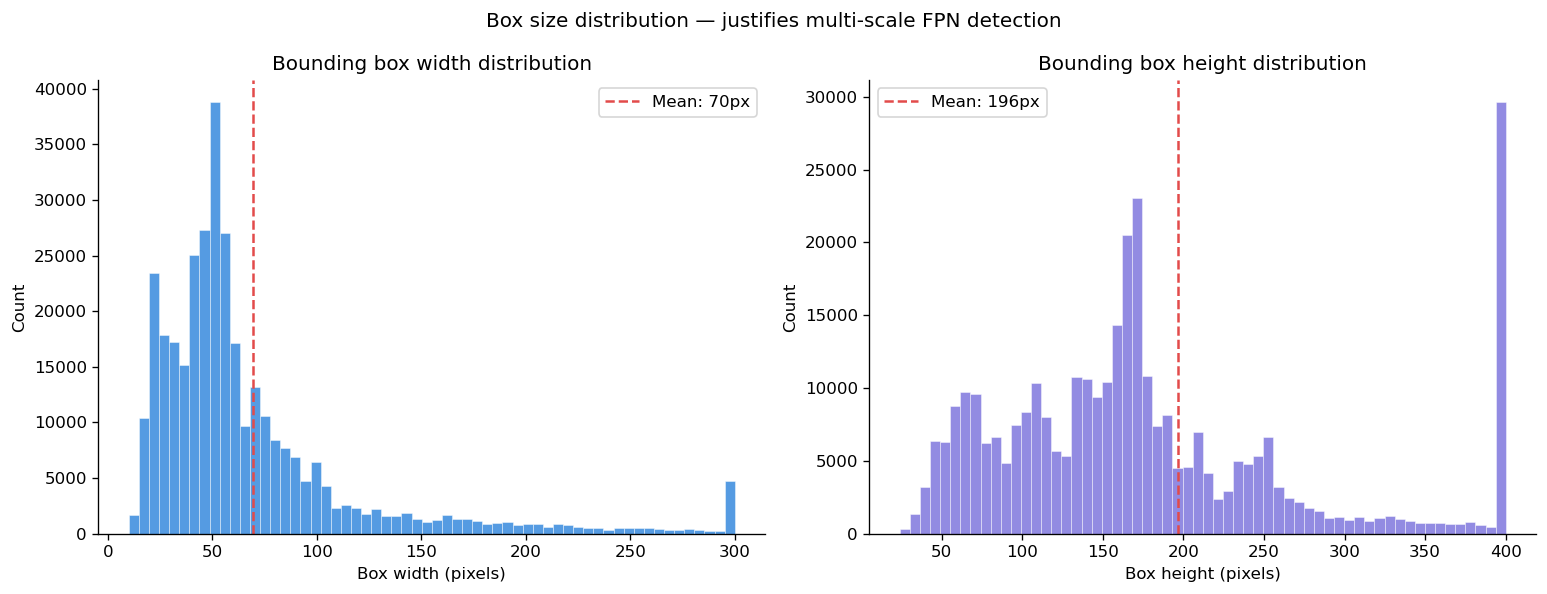

Width  — mean: 69.7  std: 62.4  min: 10  max: 947
Height — mean: 196.4  std: 160.0  min: 24  max: 1620
Saved: box_size_distribution.png


In [14]:
all_df = pd.concat(seq_data.values(), ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Width distribution
axes[0].hist(all_df['w'].clip(0, 300), bins=60, color='#378ADD', alpha=0.85,
             edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('Box width (pixels)')
axes[0].set_ylabel('Count')
axes[0].set_title('Bounding box width distribution')
axes[0].axvline(all_df['w'].mean(), color='#E24B4A', linestyle='--',
                label=f"Mean: {all_df['w'].mean():.0f}px")
axes[0].legend()

# Height distribution
axes[1].hist(all_df['h'].clip(0, 400), bins=60, color='#7F77DD', alpha=0.85,
             edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('Box height (pixels)')
axes[1].set_ylabel('Count')
axes[1].set_title('Bounding box height distribution')
axes[1].axvline(all_df['h'].mean(), color='#E24B4A', linestyle='--',
                label=f"Mean: {all_df['h'].mean():.0f}px")
axes[1].legend()

plt.suptitle('Box size distribution — justifies multi-scale FPN detection', fontsize=12)
plt.tight_layout()
plt.savefig('box_size_distribution.png', bbox_inches='tight')
plt.show()

print(f"Width  — mean: {all_df['w'].mean():.1f}  std: {all_df['w'].std():.1f}  min: {all_df['w'].min()}  max: {all_df['w'].max()}")
print(f"Height — mean: {all_df['h'].mean():.1f}  std: {all_df['h'].std():.1f}  min: {all_df['h'].min()}  max: {all_df['h'].max()}")
print('Saved: box_size_distribution.png')

## Aspect Ratio Distribution

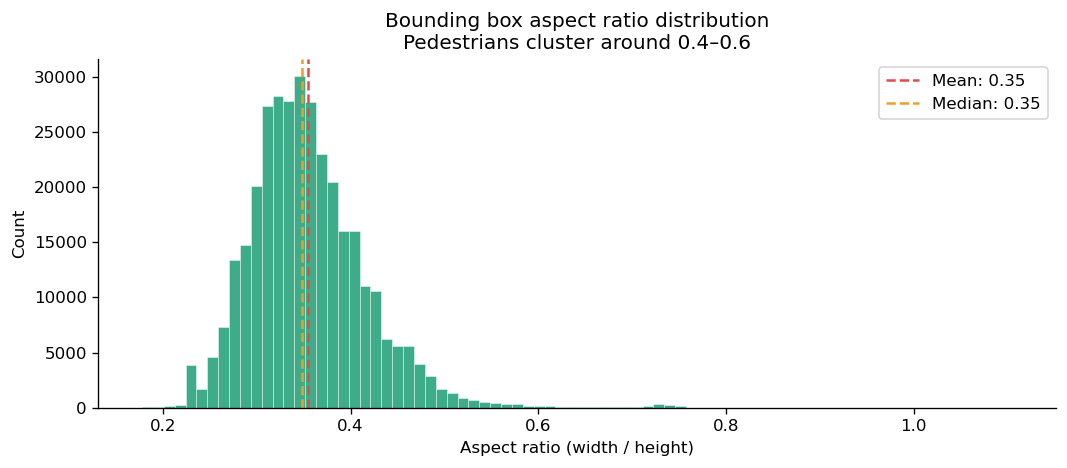

Mean aspect ratio: 0.355
% with AR < 0.3 (very thin/occluded): 16.7%
% with AR 0.3–0.6 (normal pedestrian): 82.9%
% with AR > 0.6 (wide / unusual): 0.5%
Saved: aspect_ratio.png


In [15]:
all_df['aspect_ratio'] = all_df['w'] / all_df['h'].replace(0, np.nan)
ar = all_df['aspect_ratio'].dropna().clip(0, 2)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(ar, bins=80, color='#1D9E75', alpha=0.85, edgecolor='white', linewidth=0.3)
ax.axvline(ar.mean(),   color='#E24B4A', linestyle='--', linewidth=1.5,
           label=f'Mean: {ar.mean():.2f}')
ax.axvline(ar.median(), color='#EF9F27', linestyle='--', linewidth=1.5,
           label=f'Median: {ar.median():.2f}')
ax.set_xlabel('Aspect ratio (width / height)')
ax.set_ylabel('Count')
ax.set_title('Bounding box aspect ratio distribution\nPedestrians cluster around 0.4–0.6')
ax.legend()
plt.tight_layout()
plt.savefig('aspect_ratio.png', bbox_inches='tight')
plt.show()

print(f'Mean aspect ratio: {ar.mean():.3f}')
print(f'% with AR < 0.3 (very thin/occluded): {(ar < 0.3).mean()*100:.1f}%')
print(f'% with AR 0.3–0.6 (normal pedestrian): {((ar>=0.3)&(ar<=0.6)).mean()*100:.1f}%')
print(f'% with AR > 0.6 (wide / unusual): {(ar > 0.6).mean()*100:.1f}%')
print('Saved: aspect_ratio.png')

Key Findings: The below code shows the key findings for the data analysis


In [16]:
print('=' * 55)
print('  MOT20 DATA ANALYSIS — KEY FINDINGS')
print('=' * 55)

print(f"""
Dataset size
  Total frames       : {stats_df['Frames'].sum():,}
  Total identities   : {stats_df['Unique IDs'].sum():,}
  Total annotations  : {stats_df['Annotations'].sum():,}

Crowd density
  Mean persons/frame : {all_densities.mean():.1f}
  Max persons/frame  : {all_densities.max()}
  → Extreme density motivates attention-based focusing

Occlusion
  Mean visibility    : {all_df['visibility'].mean():.2f} (1=fully visible)
  Heavily occluded   : {(all_df['visibility'] < 0.3).mean()*100:.1f}% of annotations
  → Severe occlusion motivates CBAM spatial attention

Identity tracking difficulty
  Avg track length   : {all_df.groupby(['id']).size().mean():.0f} frames
  → Short tracks + re-entries motivate robust ReID

Box scale variation
  Width range        : {all_df['w'].min()} – {all_df['w'].max()} px
  Height range       : {all_df['h'].min()} – {all_df['h'].max()} px
  → Large scale variation motivates FPN multi-scale detection
""")
print('=' * 55)
print('All plots saved. Ready for next stage: model training.')

  MOT20 DATA ANALYSIS — KEY FINDINGS

Dataset size
  Total frames       : 15,948
  Total identities   : 1,638
  Total annotations  : 336,891

Crowd density
  Mean persons/frame : 36.2
  Max persons/frame  : 52
  → Extreme density motivates attention-based focusing

Occlusion
  Mean visibility    : 0.59 (1=fully visible)
  Heavily occluded   : 28.2% of annotations
  → Severe occlusion motivates CBAM spatial attention

Identity tracking difficulty
  Avg track length   : 1982 frames
  → Short tracks + re-entries motivate robust ReID

Box scale variation
  Width range        : 10 – 947 px
  Height range       : 24 – 1620 px
  → Large scale variation motivates FPN multi-scale detection

All plots saved. Ready for next stage: model training.
